In [49]:
import pandas as pd
import numpy as np
import os

# ============================================
# 1. Load dataset
# ============================================
csv_path = (
    r"G:\Hangkai\Anttarctic Vegetation Dynamic\RF_trainning_data"
    r"\cleared_data\merged_all_data_VPD_updated.csv"
)

df = pd.read_csv(csv_path)


# ============================================
# 2. Variables for land-area–weighted averaging
# ============================================
vars_to_weight = [
    "temperature_2m",
    "uv_radiation",
    "relative_humidity",
    "volumetric_soil_water",
    "snowmelt",
    "skin_temperature",
    "runoff",
    "vapour_pressure",
    "solar_radiation",
    "10m_wind_speed",
    "precipitation",
    "icefree_area_ratio",
    "vapor_pressure_deficit",
]

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

# -----------------------------------
# Pretty names for variables
# -----------------------------------
pretty_names = {
    "temperature_2m": "2 m air temperature",
    "uv_radiation": "UV radiation",
    "relative_humidity": "Relative humidity",
    "volumetric_soil_water": "Volumetric soil water",
    "snowmelt": "Snowmelt",
    "skin_temperature": "Skin temperature",
    "runoff": "Surface runoff",
    "vapour_pressure": "Vapour pressure",
    "solar_radiation": "Solar radiation",
    "10m_wind_speed": "10 m wind speed",
    "precipitation": "Precipitation",
    "icefree_area_ratio": "Ice-free area ratio",
    "vapor_pressure_deficit": "Vapor pressure deficit",
}

pretty_info = {
    "temperature_2m": (
        "2 m air temperature", 
        "K"
    ),
    "uv_radiation": (
        "UV radiation", 
        r"J m$^{-2}$"
    ),
    "relative_humidity": (
        "Relative humidity", 
        "%"
    ),
    "volumetric_soil_water": (
        "Volumetric soil water", 
        r"m$^{3}$ m$^{-3}$"
    ),
    "snowmelt": (
        "Snowmelt",
        r"m water eq."
    ),
    "skin_temperature": (
        "Skin temperature", 
        "K"
    ),
    "runoff": (
        "Surface runoff", 
        "m"
    ),
    "vapour_pressure": (
        "Vapour pressure", 
        "hPa"
    ),
    "solar_radiation": (
        "Solar radiation", 
        r"J m$^{-2}$ d$^{-1}$"
    ),
    "10m_wind_speed": (
        "10 m wind speed", 
        r"m s$^{-1}$"
    ),
    "precipitation": (
        "Precipitation", 
        r"mm d$^{-1}$"
    ),
    "icefree_area_ratio": (
        "Ice-free area ratio", 
        "%"
    ),
    "vapor_pressure_deficit": (
        "Vapor pressure deficit", 
        "hPa"
    ),
}


vars_for_plot = list(pretty_names.keys())

# -----------------------------------
# Data to plot (pixel-level)
# -----------------------------------
df_plot = df_green.copy()   # use greened-once pixels

# Region order (IMPORTANT)
regions = ["Peninsula", "West", "East"]

# Region color map (your requested colors)
region_colors = {
    "Peninsula": "red",
    "West": "yellow",
    "East": "black"
}

# -----------------------------------
# Create 5×3 subplot figure
# -----------------------------------
n_rows, n_cols = 5, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20), dpi=600)
axes = axes.ravel()

for i, var in enumerate(vars_for_plot):
    ax = axes[i]

    sns.boxplot(
        data=df_plot,
        x="Regions",
        y=var,
        order=regions,
        palette=region_colors,
        showfliers=False,
        ax=ax
    )
    
    title, unit = pretty_info[var]

    ax.set_title(f"{title} ({unit})", fontsize=14, fontweight="bold", loc="left")
    ax.set_ylabel(unit, fontsize=10, fontweight="bold")

    # Y label only for left column
    if i % n_cols == 0:
        ax.set_ylabel("Value", fontsize=14, fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0, labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

# -----------------------------------
# Last two panels blank except legend
# -----------------------------------
for j in range(len(vars_for_plot), len(axes) - 1):
    axes[j].axis("off")

# Legend in the final panel
ax_leg = axes[-1]
ax_leg.axis("off")

handles = [
    mpatches.Patch(color=region_colors[r], label=r)
    for r in regions
]

leg = ax_leg.legend(
    handles=handles,
    title="Region",
    loc="center",
    fontsize=20,
    title_fontsize=22,
    frameon=False,
)

# Make legend title bold
leg.get_title().set_fontweight("bold")

# Make each label bold
for text in leg.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Distribution_of_Environmental_Variables.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pymannkendall as mk
from tqdm import tqdm  # if not installed, run: pip install tqdm

sns.set(style="whitegrid")

# ================================
# 1. Load data
# ================================
csv_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\RF_trainning_data\cleared_data\merged_all_data_VPD_updated.csv"
df = pd.read_csv(csv_path)

# ================================
# 2. Define "ever-greening" pixels
#    Here we use vegetation_area_ratio > 0
# ================================
greenness_by_pixel = (
    df.groupby(["latitude", "longitude"])["vegetation_area_ratio"]
      .max()
      .reset_index()
)

greenness_by_pixel["ever_green"] = greenness_by_pixel["vegetation_area_ratio"] > 0

# Keep only pixels that had greenness at least once
green_pixels = greenness_by_pixel[greenness_by_pixel["ever_green"]]
print("Number of pixels that ever had greenness:",
      green_pixels.shape[0])

# Merge ever_green flag back to full dataframe
df = df.merge(
    green_pixels[["latitude", "longitude", "ever_green"]],
    on=["latitude", "longitude"],
    how="left"
)

df["ever_green"] = df["ever_green"].fillna(False)

# Subset to ever-greening pixels only
df_green = df[df["ever_green"]].copy()
print("Rows in df_green:", df_green.shape[0])

# ================================
# 3. Variables to analyze with MK
#    You can extend this list if needed
# ================================
vars_for_mk = [
    "temperature_2m",
    "uv_radiation",
    "relative_humidity",
    "volumetric_soil_water",
    "snowmelt",
    "skin_temperature",
    "runoff",
    "vapour_pressure",
    "solar_radiation",
    "10m_wind_speed",
    "precipitation",
    "icefree_area_ratio",
    "vapor_pressure_deficit",
]

pretty_names = {
    "temperature_2m": "2 m air temperature",
    "uv_radiation": "UV radiation",
    "relative_humidity": "Relative humidity",
    "volumetric_soil_water": "Volumetric soil water",
    "snowmelt": "Snowmelt",
    "skin_temperature": "Skin temperature",
    "runoff": "Surface runoff",
    "vapour_pressure": "Vapour pressure",
    "solar_radiation": "Solar radiation",
    "10m_wind_speed": "10 m wind speed",
    "precipitation": "Precipitation",
    "icefree_area_ratio": "Ice-free area ratio",
    "vapor_pressure_deficit": "Vapor pressure deficit",
}

# ================================
# 4. Run MK test per pixel for each variable
# ================================
results = []

grouped = df_green.groupby(["latitude", "longitude"], sort=False)

for (lat, lon), g in tqdm(grouped, desc="Running MK per pixel"):
    # Sort by year (panel is complete, but sorting is safer)
    g_sorted = g.sort_values("year")

    region = g_sorted["Regions"].iloc[0]
    n_years_pixel = g_sorted["year"].nunique()

    out_row = {
        "latitude": lat,
        "longitude": lon,
        "Regions": region,
        "n_years": n_years_pixel,
    }

    for var in vars_for_mk:
        series = g_sorted[var].values.astype(float)

        # If the series is all NaN or too short, skip MK
        if np.all(np.isnan(series)) or len(series) < 3:
            slope = np.nan
            pval = np.nan
        else:
            res = mk.original_test(series)
            slope = res.slope
            pval = res.p

        out_row[f"{var}_slope"] = slope
        out_row[f"{var}_p"] = pval

    results.append(out_row)

mk_df = pd.DataFrame(results)

# (Optional) save MK results to CSV if you want
out_mk_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\RF_trainning_data\cleared_data\mk_trend_per_pixel_multi_vars_greenness.csv"
mk_df.to_csv(out_mk_path, index=False)
print("MK per-pixel results saved to:")
print(out_mk_path)

# ================================
# 5. For each variable: percentages of trend categories
#    (increasing, decreasing, no significant trend)
# ================================
summary_rows = []

for var in vars_for_mk:
    p_col = f"{var}_p"
    s_col = f"{var}_slope"

    # Valid pixels where MK test was computed
    valid = mk_df[p_col].notna()
    n_valid = valid.sum()

    if n_valid == 0:
        pct_inc = np.nan
        pct_dec = np.nan
        pct_no  = np.nan
    else:
        p_vals = mk_df.loc[valid, p_col]
        slopes = mk_df.loc[valid, s_col]

        # Significant increasing trend: p < 0.05 and slope > 0
        n_inc = ((p_vals < 0.05) & (slopes > 0)).sum()

        # Significant decreasing trend: p < 0.05 and slope < 0
        n_dec = ((p_vals < 0.05) & (slopes < 0)).sum()

        # No significant trend: everything else
        n_no = n_valid - n_inc - n_dec

        pct_inc = 100.0 * n_inc / n_valid
        pct_dec = 100.0 * n_dec / n_valid
        pct_no  = 100.0 * n_no  / n_valid

    summary_rows.append({
        "variable": var,
        "pretty_name": pretty_names.get(var, var),
        "n_valid": n_valid,
        "pct_increasing": pct_inc,   # significant increasing trend
        "pct_decreasing": pct_dec,   # significant decreasing trend
        "pct_no_trend": pct_no       # no significant trend
    })

summary_df = pd.DataFrame(summary_rows)
print("\nTrend category summary:")
print(summary_df)

Number of pixels that ever had greenness: 40298
Rows in df_green: 886556


Running MK per pixel: 100%|██████████████████████████████████████████████████████| 40298/40298 [12:54<00:00, 52.05it/s]


MK per-pixel results saved to:
G:\Hangkai\Anttarctic Vegetation Dynamic\RF_trainning_data\cleared_data\mk_trend_per_pixel_multi_vars_greenness.csv

Trend category summary:
                  variable             pretty_name  n_valid  pct_increasing  \
0           temperature_2m     2 m air temperature    40298        5.499032   
1             uv_radiation            UV radiation    40298        1.340017   
2        relative_humidity       Relative humidity    40298       20.380664   
3    volumetric_soil_water   Volumetric soil water    40298       32.468113   
4                 snowmelt                Snowmelt    40298        0.012408   
5         skin_temperature        Skin temperature    40298       10.246166   
6                   runoff          Surface runoff    40298        0.612934   
7          vapour_pressure         Vapour pressure    40298       18.574123   
8          solar_radiation         Solar radiation    40298        1.344980   
9           10m_wind_speed         10 

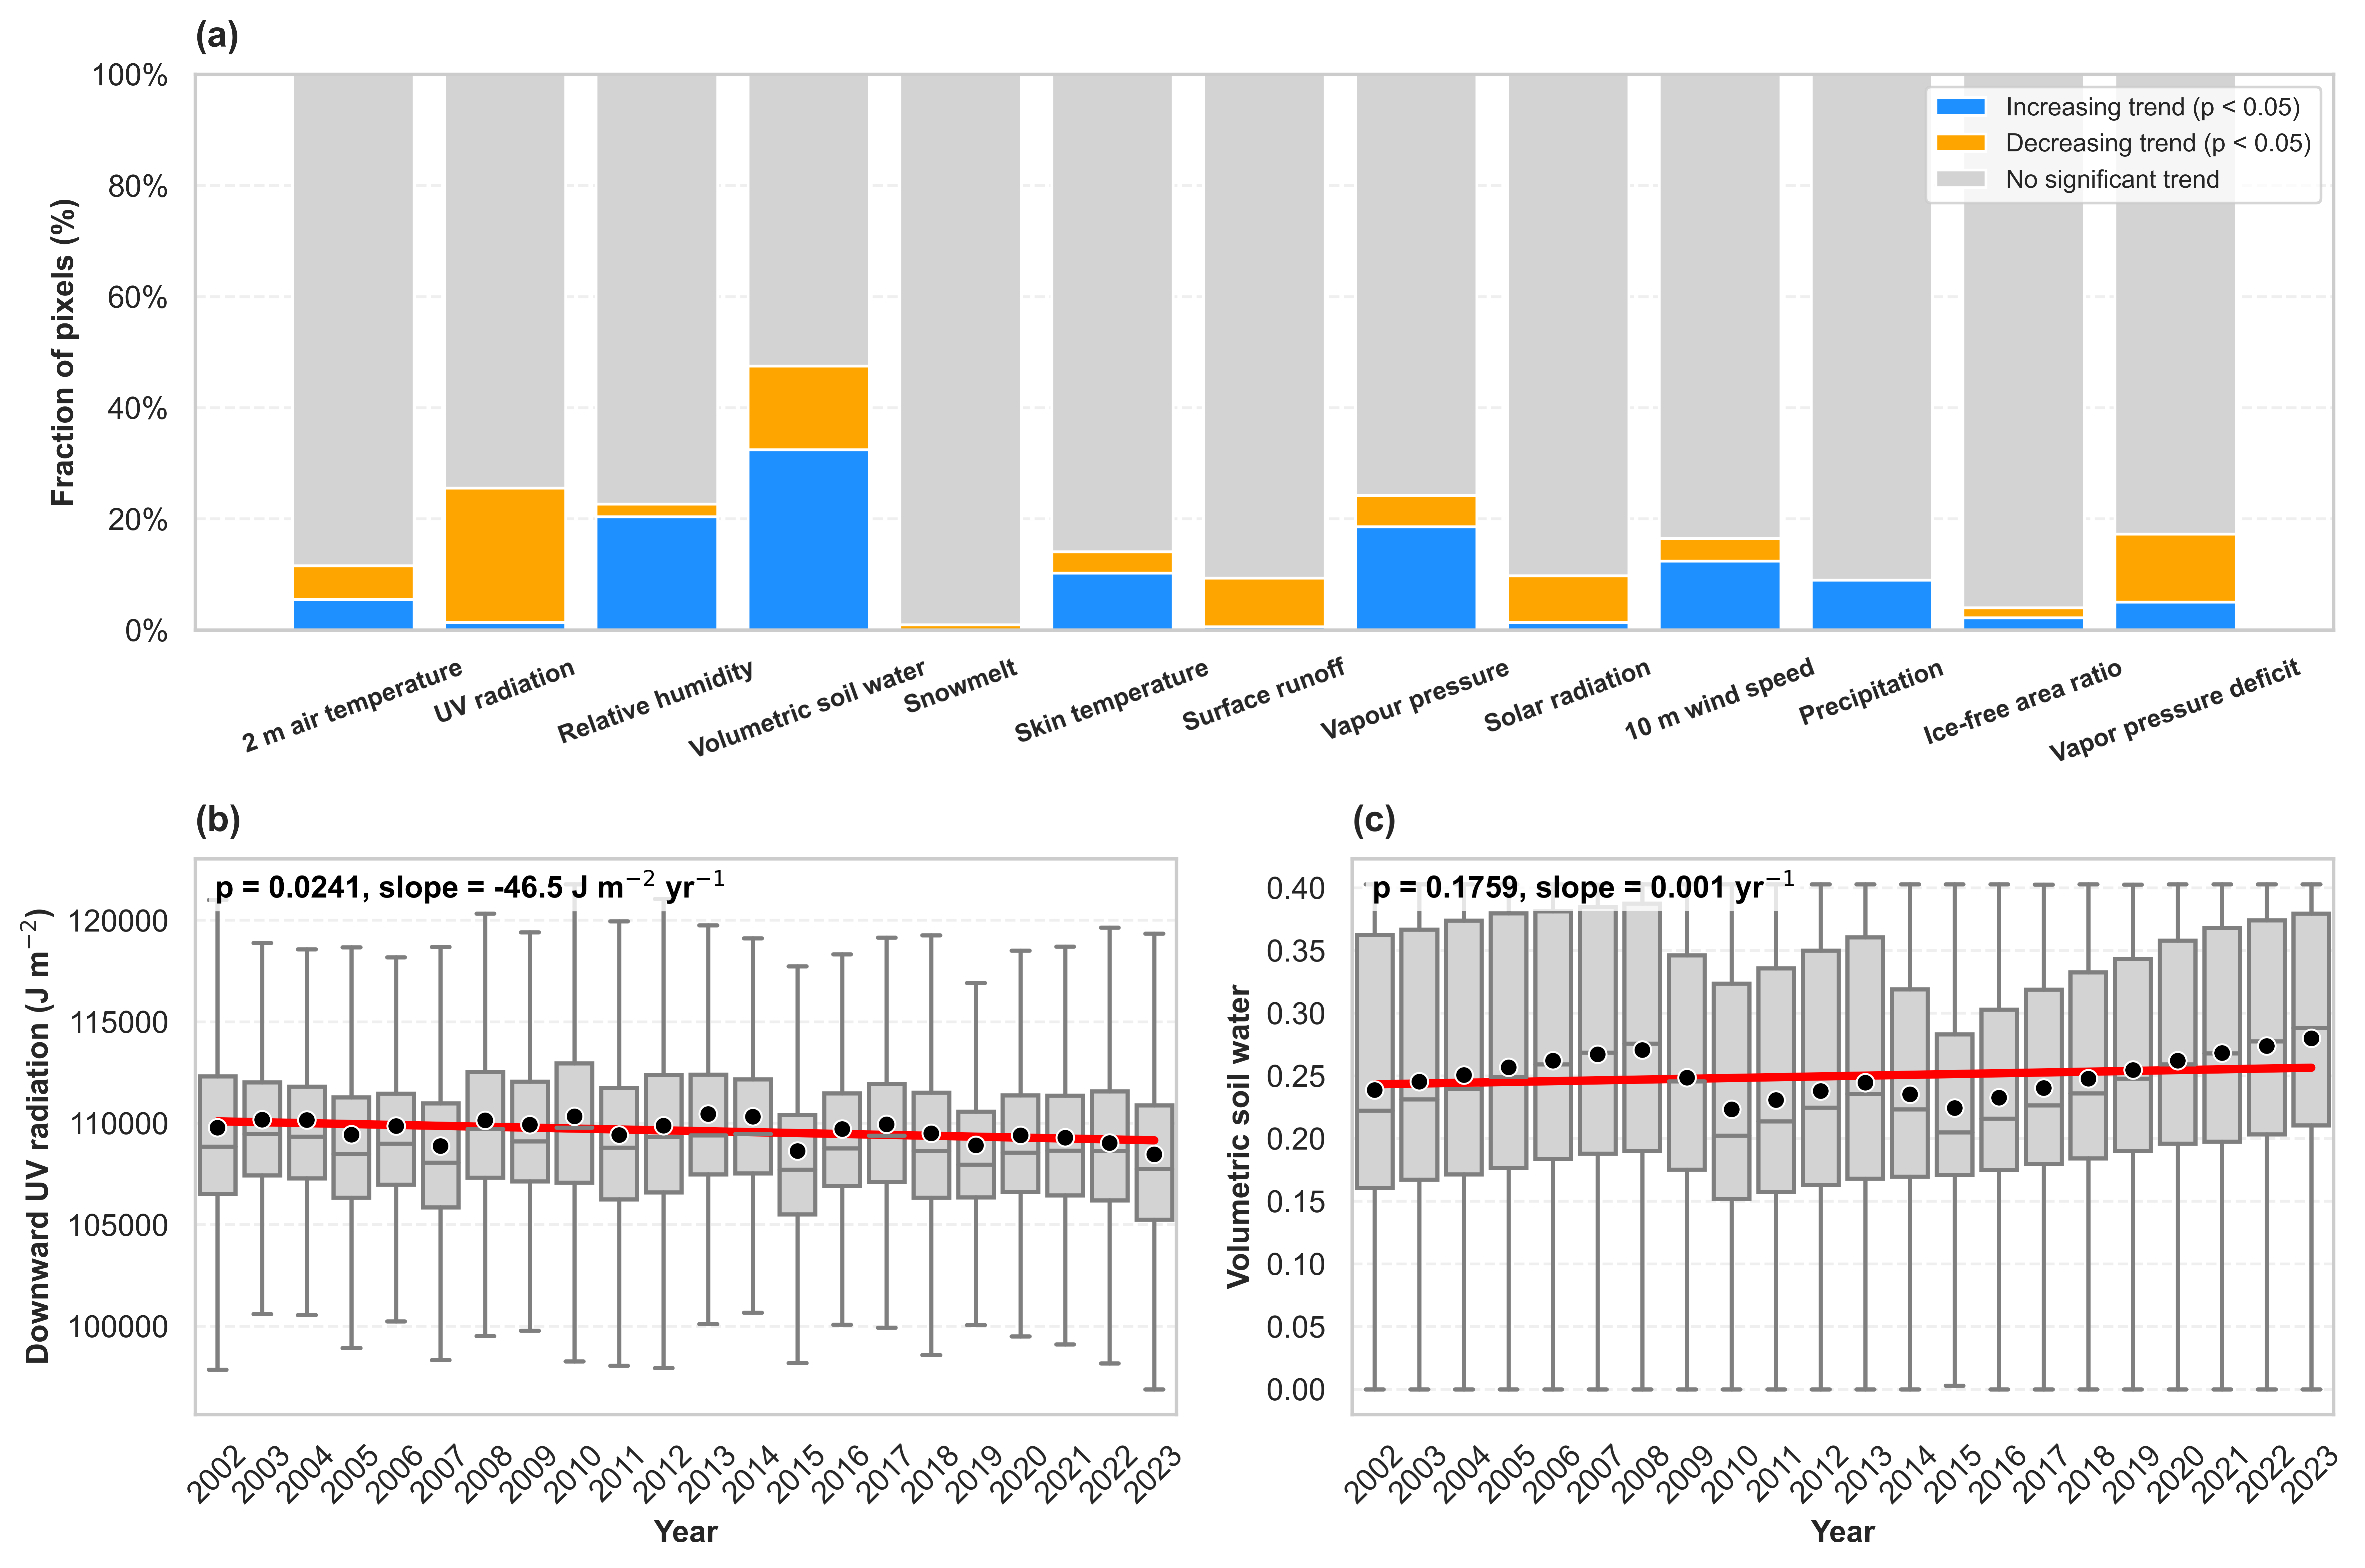

In [46]:
# ================================
# 7. Plot figure with three subplots
#    Row 1: (a) MK trend categories bar chart (full width)
#    Row 2: (b) UV boxplot + regression, (c) Soil moisture boxplot + regression
# ================================
from matplotlib import gridspec

fig = plt.figure(figsize=(12, 8), dpi=600)  # taller figure for two rows
gs = gridspec.GridSpec(
    2, 2,                # 2 rows, 2 columns
    height_ratios=[1, 1] # adjust if you want top row taller (e.g., [1.1, 1])
)

# ---------- Subplot (a): bar chart of trend categories (top row, spans both columns) ----------
ax1 = fig.add_subplot(gs[0, :])  # row 0, all columns

x_pos = np.arange(len(summary_df))

# Use the three-category percentages from summary_df
pct_inc = summary_df["pct_increasing"].values
pct_dec = summary_df["pct_decreasing"].values
pct_no  = summary_df["pct_no_trend"].values
labels  = summary_df["pretty_name"].values

# Stacked bars: increasing, decreasing, and no significant trend
ax1.bar(
    x_pos,
    pct_inc,
    label="Increasing trend (p < 0.05)",
    color="dodgerblue"
)
ax1.bar(
    x_pos,
    pct_dec,
    bottom=pct_inc,
    label="Decreasing trend (p < 0.05)",
    color="orange"
)
ax1.bar(
    x_pos,
    pct_no,
    bottom=pct_inc + pct_dec,
    label="No significant trend",
    color="lightgray"
)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=20, ha="center", fontsize=9, fontweight="bold")
ax1.set_ylabel("Fraction of pixels (%)", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax1.legend(fontsize=9, loc="upper right")

# Subplot label (a)
ax1.text(
    0.0, 1.05, "(a)",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold"
)


# ---------- Helper: boxplot + regression on annual means ----------
def boxplot_with_reg(ax, df, var, y_label, panel_label, unit_text=""):
    """
    Draw yearly boxplots of 'var' over df, overlay annual mean + regression line,
    and annotate MK p and slope based on annual means.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to draw on.
    df : pandas.DataFrame
        Input dataframe; must contain 'year' and the variable column.
    var : str
        Column name of the environmental variable.
    y_label : str
        Y-axis label.
    panel_label : str
        Subplot label, e.g. "(b)" or "(c)".
    unit_text : str, optional
        Physical unit of the variable (e.g., 'J m$^{-2}$'). Used in slope text.
    """
    # Sort years and use them as an explicit order on the x-axis
    years = np.sort(df["year"].unique())
    x_idx = np.arange(len(years))

    # ---------- 1) Boxplot: full distribution per year ----------
    sns.boxplot(
        x="year",
        y=var,
        data=df,
        order=years,
        showfliers=False,
        color="lightgray",
        ax=ax
    )

    # ---------- 2) Annual mean series ----------
    yearly = (
        df.groupby("year")[var]
          .mean()
          .reindex(years)
          .reset_index()
    )
    y_mean = yearly[var].astype(float).values

    # ---------- 3) Scatter of annual means ----------
    ax.scatter(
        x_idx,
        y_mean,
        s=40,
        color="black",
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
        label="Annual mean"
    )

    # ---------- 4) Linear regression line (on annual means) ----------
    if len(y_mean) >= 2 and not np.all(np.isnan(y_mean)):
        coef = np.polyfit(x_idx, y_mean, 1)  # slope, intercept
        y_fit = np.polyval(coef, x_idx)
        ax.plot(
            x_idx,
            y_fit,
            color="red",
            lw=3,
            zorder=2,
            label="Linear trend"
        )

    # ---------- 5) Mann–Kendall test on annual means ----------
    if len(y_mean) >= 3 and not np.all(np.isnan(y_mean)):
        mk_res = mk.original_test(y_mean)
        p = mk_res.p
        slope = mk_res.slope
        if unit_text:
            text = rf"p = {p:.4f}, slope = {slope:.1f} {unit_text} yr$^{{-1}}$"
        else:
            text = rf"p = {p:.4f}, slope = {slope:.3f} yr$^{{-1}}$"
    else:
        text = "MK test not computed"

    ax.text(
        0.02, 0.93, text,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none")
    )

    # ---------- 6) Axis formatting ----------
    ax.set_xticks(x_idx)
    ax.set_xticklabels(years, rotation=45)
    ax.set_xlabel("Year", fontsize=11, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # Subplot label, e.g. (b) or (c)
    ax.text(
        0.0, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold"
    )


# ---------- Subplot (b): UV boxplot + regression (bottom-left) ----------
ax2 = fig.add_subplot(gs[1, 0])
boxplot_with_reg(
    ax=ax2,
    df=df_green,
    var="uv_radiation",
    y_label=r"Downward UV radiation (J m$^{-2}$)",
    panel_label="(b)",
    unit_text="J m$^{-2}$",
)

# ---------- Subplot (c): soil moisture boxplot + regression (bottom-right) ----------
ax3 = fig.add_subplot(gs[1, 1])
boxplot_with_reg(
    ax=ax3,
    df=df_green,
    var="volumetric_soil_water",
    y_label="Volumetric soil water",
    panel_label="(c)",
    unit_text=""  # dimensionless, slope in yr^-1
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Trend_of_Key_Environmental_Variables.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()